<a href="https://colab.research.google.com/github/kosaquito/ProcesamientoDelHabla/blob/main/TP2_procesamiento_PDF_Martinez_Martin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tecnicatura en Inteligencia Artificial y Ciencia de Datos (ISSD)**
# TP2 — Procesamiento de archivos PDF

**Materia:** Procesamiento del Habla
**Docente:** Ana Laura Diedrichs
**Alumno:** Martin R. Martinez
**Fecha de entrega:** octubre 2026

---

## Objetivo

Construir en Python un flujo de trabajo que transforme un documento PDF en datos estructurados y listos para analizar:

1. **Descarga** automatizada del PDF desde un enlace público (`requests`).
2. **Inspección** de metadatos (título, autor, páginas, software de creación).
3. **Extracción cruda** del texto y **análisis de separadores** (párrafos, secciones, caracteres especiales).
4. **Extracción de una tabla** y conversión a `DataFrame` de pandas, con limpieza.
5. **Preprocesamiento NLP** de una página narrativa (tokenización, stop words, puntuación) y gráfico de las 15 palabras más frecuentes.

## Documento elegido

**"DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning"** (DeepSeek-AI, enero 2025).

Es el reporte técnico del modelo de razonamiento DeepSeek-R1, publicado también en arXiv (2501.12948). Lo descargo desde el repositorio público oficial del proyecto en GitHub.

¿Por qué este documento?
- Es un **reporte técnico real generado con LaTeX** (texto extraíble, no escaneado).
- Tiene **tablas sin bordes** (estilo *booktabs*), que son un desafío realista para la extracción: las herramientas que detectan tablas por líneas dibujadas no las encuentran.
- Tiene **páginas de texto narrativo puro** (la introducción) y además fórmulas, figuras, citas y referencias. Eso permite ver de cerca los problemas de limpieza.
- El tema (LLMs y razonamiento) está directamente relacionado con la carrera.

## 0. Instalación y librerías

| Librería | Para qué la uso |
|---|---|
| `requests` | Descargar el PDF por HTTP |
| `PyMuPDF` (`pymupdf`, antes `fitz`) | Metadatos, texto crudo, bloques y flujo de contenido del PDF |
| `pdfplumber` | Extracción de tablas y posición de cada palabra/línea |
| `pandas` | Estructurar la tabla |
| `spaCy` (`en_core_web_sm`) | Tokenización, stop words y puntuación (el documento está en inglés) |
| `matplotlib` | Gráfico de frecuencias |

In [1]:
# En Google Colab pymupdf y pdfplumber no vienen instalados
!pip install -q pymupdf pdfplumber
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 63.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 60.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import os
import re
import collections
import unicodedata

import requests
import pymupdf          # PyMuPDF (el nombre histórico del módulo era "fitz")
import pdfplumber
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import spacy

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

## 1. Descarga e inspección

### 1.1 Descarga con `requests`

Descargo el archivo en modo *stream* (por bloques), así no se carga todo en memoria de una vez. Antes de guardarlo verifico tres cosas:
- que el servidor respondió `200 OK` (`raise_for_status()`),
- que el tipo de contenido sea el esperado,
- que los primeros bytes del archivo sean `%PDF` (la "firma" de todo archivo PDF). Si el enlace devolviera una página HTML de error, lo detectaría acá.

In [24]:
URL_PDF = "https://raw.githubusercontent.com/deepseek-ai/DeepSeek-R1/main/DeepSeek_R1.pdf"
ARCHIVO = "DeepSeek_R1.pdf"

def descargar_pdf(url, destino):
    # Descarga un PDF por bloques y valida que realmente sea un PDF
    resp = requests.get(url, stream=True, timeout=60)
    resp.raise_for_status()
    with open(destino, "wb") as f:
        for bloque in resp.iter_content(chunk_size=8192):
            f.write(bloque)
    with open(destino, "rb") as f:
        firma = f.read(4)
    if firma != b"%PDF":
        raise ValueError(f"El archivo descargado no es un PDF (firma: {firma!r})")
    return resp

resp = descargar_pdf(URL_PDF, ARCHIVO)
print("Código HTTP      :", resp.status_code)
print("Content-Type     :", resp.headers.get("Content-Type"))
print("Tamaño en disco  :", round(os.path.getsize(ARCHIVO) / 1024, 1), "KB")

Código HTTP      : 200
Content-Type     : application/octet-stream
Tamaño en disco  : 1297.8 KB


> **Observación:** GitHub sirve el archivo como `application/octet-stream` (binario genérico) y no como `application/pdf`. Por eso no alcanza con mirar el `Content-Type`: verificar la firma `%PDF` es más confiable.

### 1.2 Metadatos

PyMuPDF expone los metadatos del diccionario `/Info` del PDF en `doc.metadata`.

In [4]:
doc = pymupdf.open(ARCHIVO)
meta = doc.metadata

print("Título              :", repr(meta.get("title")))
print("Autor               :", repr(meta.get("author")))
print("Número de páginas   :", doc.page_count)
print("Software de creación:", meta.get("creator"))
print("Productor (motor)   :", meta.get("producer"))
print("Fecha de creación   :", meta.get("creationDate"))
print("Versión de PDF      :", meta.get("format"))
print("Encriptado          :", doc.is_encrypted)

Título              : ''
Autor               : ''
Número de páginas   : 22
Software de creación: LaTeX with hyperref
Productor (motor)   : pdfTeX-1.40.26
Fecha de creación   : D:20250123075355Z
Versión de PDF      : PDF 1.5
Encriptado          : False


**Hallazgo:** los campos **título y autor están vacíos** (`''`). Pasa seguido con PDFs generados con LaTeX: si el autor no completa `\hypersetup{pdftitle=..., pdfauthor=...}`, el archivo sale sin esos metadatos. El software de creación sí está: **LaTeX con el paquete hyperref**, compilado con **pdfTeX 1.40.26**.

Como el título igual se necesita, lo recupero **del contenido**: en un paper, el título es el texto con la fuente más grande de la primera página. PyMuPDF da el tamaño de fuente de cada fragmento (`span`) con `get_text("dict")`.

> Detalle que encontré al probar: el título ocupa dos renglones y **no tienen exactamente el mismo tamaño** (15,84 pt y 15,94 pt), porque LaTeX escala levemente cada renglón al justificar. Con una comparación exacta (`==`) solo recuperaba "Reinforcement Learning", así que uso una tolerancia de 0,5 pt (con 1 pt se colaba también la palabra "Abstract", que está en 15 pt).

In [5]:
def titulo_por_tamano_fuente(pagina):
    # Devuelve el texto escrito con la fuente más grande de la página
    spans = []
    for bloque in pagina.get_text("dict")["blocks"]:
        for linea in bloque.get("lines", []):
            for span in linea["spans"]:
                if span["text"].strip():
                    spans.append((round(span["size"], 1), span["text"].strip()))
    tam_max = max(s[0] for s in spans)
    # Tolerancia de 0,5 pt: el justificado de LaTeX escala apenas cada renglón (15.8 vs 15.9 pt)
    titulo = " ".join(t for s, t in spans if s >= tam_max - 0.5)
    return re.sub(r"\s+", " ", titulo), tam_max

titulo, tam = titulo_por_tamano_fuente(doc[0])
print(f"Título inferido (fuente {tam} pt): {titulo}")

Título inferido (fuente 15.9 pt): DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning


## 2. Extracción cruda y análisis de separadores

### 2.1 ¿Qué función da el texto "más crudo"?

En PyMuPDF la función es **`page.get_text("text")`** (o simplemente `page.get_text()`). Devuelve el texto de la página en orden de lectura, línea por línea, sin interpretar párrafos ni formato.

Para ver los caracteres invisibles (`\n`, `\t`, etc.) imprimo la representación con **`repr()`**: así aparecen escapados en vez de "ejecutarse".

In [6]:
pagina_intro = doc[2]          # página 3 del PDF (índice 0) = "1. Introduction"
texto_crudo = pagina_intro.get_text("text")

print(repr(texto_crudo[:900]))

'1. Introduction\nIn recent years, Large Language Models (LLMs) have been undergoing rapid iteration and\nevolution (Anthropic, 2024; Google, 2024; OpenAI, 2024a), progressively diminishing the gap\ntowards Artificial General Intelligence (AGI).\nRecently, post-training has emerged as an important component of the full training pipeline.\nIt has been shown to enhance accuracy on reasoning tasks, align with social values, and adapt\nto user preferences, all while requiring relatively minimal computational resources against\npre-training. In the context of reasoning capabilities, OpenAI’s o1 (OpenAI, 2024b) series models\nwere the first to introduce inference-time scaling by increasing the length of the Chain-of-\nThought reasoning process. This approach has achieved significant improvements in various\nreasoning tasks, such as mathematics, coding, and scientific reasoning. However, the challenge\nof '


### 2.2 Un nivel más abajo: el flujo de contenido del PDF

Para entender *por qué* extraer texto de un PDF es difícil, miro lo que hay **realmente guardado** dentro del archivo para esa página: el *content stream*, con `page.read_contents()`.

In [25]:
contenido = pagina_intro.read_contents()
print(contenido[:700].decode("latin-1"))

0 g 0 G
0 g 0 G
0 g 0 G
0 g 0 G
BT
/F117 12.9514 Tf 70.866 745.891 Td [(1.)]TJ
0 g 0 G
 [-500(Introduction)]TJ
0 g 0 G
/F121 10.9091 Tf 1.02 0 0 1 70.866 720.586 Tm [(In)-320(r)18(ecent)-320(years,)-338(Lar)18(ge)-320(Language)-320(Models)-319(\050LLMs\051)-320(have)-320(been)-319(under)17(going)-319(rapid)-320(iteration)-320(and)]TJ 1.014 0 0 1 70.866 707.037 Tm [(evolution)-247(\050Anthr)18(opic,)-247(2024;)-247(Google,)-247(2024;)-247(OpenAI,)-247(2024a\051,)-247(pr)18(ogr)17(essively)-247(di)1(minishing)-247(the)-247(gap)]TJ 1 0 0 1 70.866 693.488 Tm [(towar)18(ds)-250(Arti\002cial)-250(General)-250(Intelligence)-250(\050AGI\051.)]TJ 0.987 0 0 1 87.803 673.164 Tm [(Recently)113(,)-253(po


**Qué muestra esto:**
- El PDF **no guarda palabras ni párrafos**: guarda *instrucciones de dibujo*. `Tm`/`Td` posicionan el cursor en coordenadas (x, y) y `TJ` dibuja fragmentos de texto.
- **Los espacios no existen como caracteres.** Entre `(In)` y `(r)` aparece un número como `-320`, que es un desplazamiento horizontal. El extractor tiene que *deducir* que ese hueco es un espacio.
- Las palabras aparecen **partidas por el ajuste de espaciado entre letras (kerning)**: `(r)18(ecent)` = "recent", `(Lar)18(ge)` = "Large".
- Las ligaduras tipográficas se guardan como un solo glifo: `Arti\002cial` es "Arti**fi**cial" (el par "fi" es el carácter `\002` de la fuente).

Por eso distintas librerías pueden devolver textos distintos del mismo PDF. Lo compruebo comparando con `pdfplumber`:

In [8]:
with pdfplumber.open(ARCHIVO) as pdf:
    texto_plumber = pdf.pages[2].extract_text()

# Busco la frase "This approach has achieved significant improvements" en ambos textos
i = texto_crudo.find("This approach")
j = texto_plumber.find("Thisapproach")
print("PyMuPDF   :", repr(texto_crudo[i:i+80]))
print("pdfplumber:", repr(texto_plumber[j:j+80] if j >= 0 else texto_plumber[:80]))

PyMuPDF   : 'This approach has achieved significant improvements in various\nreasoning tasks, '
pdfplumber: 'Thisapproachhasachievedsignificantimprovementsinvarious\nreasoningtasks,suchasmat'


Con la configuración por defecto, **pdfplumber pega palabras** ("Thisapproachhasachieved...") en algunas líneas. Esas líneas están justificadas, y LaTeX achica los espacios hasta quedar por debajo de la tolerancia (`x_tolerance=3`) que pdfplumber usa para decidir si hay un espacio. PyMuPDF las separa bien. **Por eso uso PyMuPDF para el texto corrido y pdfplumber solo para las tablas**, donde su información de posiciones es más útil.

### 2.3 Inventario de caracteres separadores

Extraigo el texto de **todo** el documento y cuento los caracteres de control y de espaciado que podrían funcionar como separadores.

In [9]:
texto_completo = "".join(p.get_text("text") for p in doc)

candidatos = {
    "\\n  (salto de línea)":          "\n",
    "\\n\\n (línea en blanco)":       "\n\n",
    "\\r  (retorno de carro)":        "\r",
    "\\t  (tabulación)":              "\t",
    "\\f  (salto de página)":         "\f",
    "\\xa0 (espacio duro)":           "\xa0",
    "'  ' (2+ espacios seguidos)":    "  ",
    "'-\\n' (guion al final de línea)": "-\n",
    "• (viñeta)":                     "•",
}
inventario = pd.DataFrame(
    [(nombre, texto_completo.count(c)) for nombre, c in candidatos.items()],
    columns=["Secuencia", "Ocurrencias"],
)
print("Total de caracteres extraídos:", len(texto_completo))
inventario

Total de caracteres extraídos: 56810


,Secuencia,Ocurrencias
0,\n (salto de línea),1381
1,\n\n (línea en blanco),0
2,\r (retorno de carro),0
3,\t (tabulación),0
4,\f (salto de página),0
5,\xa0 (espacio duro),0
6,' ' (2+ espacios seguidos),0
7,'-\n' (guion al final de línea),66
8,• (viñeta),15


También busco los caracteres **no ASCII** más frecuentes, porque suelen ser una fuente de "ruido" en la limpieza:

In [10]:
no_ascii = collections.Counter(ch for ch in texto_completo if ord(ch) > 127)
pd.DataFrame(
    [(repr(ch), unicodedata.name(ch, "?"), n) for ch, n in no_ascii.most_common(12)],
    columns=["Carácter", "Nombre Unicode", "Ocurrencias"],
)

,Carácter,Nombre Unicode,Ocurrencias
0,'’',RIGHT SINGLE QUOTATION MARK,28
1,'𝑎',MATHEMATICAL ITALIC SMALL A,24
2,'𝑥',MATHEMATICAL ITALIC SMALL X,22
3,'𝑖',MATHEMATICAL ITALIC SMALL I,20
4,'·',MIDDLE DOT,18
5,'−',MINUS SIGN,17
6,'𝑜',MATHEMATICAL ITALIC SMALL O,16
7,'•',BULLET,15
8,'𝜋',MATHEMATICAL ITALIC SMALL PI,15
9,'𝑟',MATHEMATICAL ITALIC SMALL R,14


### 2.4 Párrafos, secciones y capítulos: ¿cómo están separados?

**Párrafos.** En el texto plano **no hay líneas en blanco** (`\n\n` = 0): cada línea visual termina en `\n` y un cambio de párrafo también termina en un solo `\n`. Mirando solo el texto no se distingue "fin de línea" de "fin de párrafo". La información de párrafo está en la **geometría**: PyMuPDF agrupa las líneas en **bloques** (`get_text("blocks")`), y cada bloque coincide con un párrafo.

In [11]:
bloques = pagina_intro.get_text("blocks")   # (x0, y0, x1, y1, texto, nro_bloque, tipo)
print(f"La página 3 tiene {len(bloques)} bloques:\n")
for x0, y0, x1, y1, txt, nro, tipo in bloques:
    lineas = txt.count("\n")
    print(f"bloque {nro}: y={y0:6.1f}→{y1:6.1f} | {lineas:2d} líneas | {txt[:70]!r}")

La página 3 tiene 7 bloques:

bloque 0: y=  86.6→  99.5 |  1 líneas | '1. Introduction\n'
bloque 1: y= 113.4→ 151.5 |  3 líneas | 'In recent years, Large Language Models (LLMs) have been undergoing rap'
bloque 2: y= 161.0→ 334.4 | 13 líneas | 'Recently, post-training has emerged as an important component of the f'
bloque 3: y= 343.9→ 476.7 | 10 líneas | 'In this paper, we take the first step toward improving language model '
bloque 4: y= 486.1→ 632.5 | 11 líneas | 'However, DeepSeek-R1-Zero encounters challenges such as poor readabili'
bloque 5: y= 641.9→ 734.1 |  7 líneas | 'We further explore distillation from DeepSeek-R1 to smaller dense mode'
bloque 6: y= 778.9→ 789.8 |  1 líneas | '3\n'


Con los bloques puedo **reconstruir párrafos limpios**: uno los renglones de cada bloque y deshago los cortes de palabra con guion al final de línea. Hay que tener cuidado: no todo `-\n` es una palabra cortada. "Chain-of-\nThought" tiene un guion que es parte de la palabra compuesta. Solo uno sin guion cuando la línea siguiente empieza en **minúscula** y lo anterior no es un nombre con guion.

In [12]:
def limpiar_bloque(txt):
    # Une las líneas de un bloque en un párrafo
    txt = re.sub(r"(?<=[a-z])-\n(?=[a-z])", "", txt)   # palabra cortada: "pro-\ncess" -> "process"
    txt = re.sub(r"-\n", "-", txt)                     # guion real: "Chain-of-\nThought" -> "Chain-of-Thought"
    txt = re.sub(r"\s*\n\s*", " ", txt)                # el resto de los saltos -> espacio
    return txt.strip()

parrafos = [limpiar_bloque(b[4]) for b in bloques if b[6] == 0]   # tipo 0 = texto (1 = imagen)
for k, p in enumerate(parrafos[:3]):
    print(f"[Párrafo {k}] {p[:260]}{'...' if len(p) > 260 else ''}\n")

[Párrafo 0] 1. Introduction

[Párrafo 1] In recent years, Large Language Models (LLMs) have been undergoing rapid iteration and evolution (Anthropic, 2024; Google, 2024; OpenAI, 2024a), progressively diminishing the gap towards Artificial General Intelligence (AGI).

[Párrafo 2] Recently, post-training has emerged as an important component of the full training pipeline. It has been shown to enhance accuracy on reasoning tasks, align with social values, and adapt to user preferences, all while requiring relatively minimal computational...



**Secciones.** Los títulos de sección **no tienen un carácter separador propio**: son una línea más terminada en `\n`. Se reconocen por su **patrón de numeración** (`1.`, `2.2.`, `2.3.4.`) seguido de un texto con mayúscula inicial y por estar escritos en **negrita**. Lo detecto con una expresión regular y lo confirmo con la fuente (PyMuPDF marca negrita con el bit 16 de `span["flags"]`).

In [13]:
patron_seccion = re.compile(r"^(\d+(?:\.\d+)*)\.\s+([A-Z][^\n]{2,80})$")

secciones = []
for nro_pag, pagina in enumerate(doc, start=1):
    for bloque in pagina.get_text("dict")["blocks"]:
        for linea in bloque.get("lines", []):
            texto_linea = "".join(s["text"] for s in linea["spans"]).strip()
            m = patron_seccion.match(texto_linea)
            negrita = all(s["flags"] & 16 for s in linea["spans"] if s["text"].strip())
            if m and negrita:
                nivel = m.group(1).count(".") + 1
                secciones.append((nro_pag, nivel, m.group(1), m.group(2)))

df_secciones = pd.DataFrame(secciones, columns=["Página", "Nivel", "Número", "Título"])
df_secciones

,Página,Nivel,Número,Título
0,3,1,1,Introduction
1,4,2,1.1,Contributions
2,4,2,1.2,Summary of Evaluation Results
3,5,1,2,Approach
4,5,2,2.1,Overview
5,5,2,2.2,DeepSeek-R1-Zero: Reinforcement Learning on th...
6,5,3,2.2.1,Reinforcement Learning Algorithm
7,6,3,2.2.2,Reward Modeling
8,6,3,2.2.3,Training Template
9,6,3,2.2.4,"Performance, Self-evolution Process and Aha Mo..."


**Capítulos / páginas.** Es un paper, así que no tiene capítulos sino secciones de primer nivel (1. Introduction, 2. Approach, 3. Experiment, ...). Tampoco hay un carácter de salto de página (`\f` = 0): la separación entre páginas existe porque **PyMuPDF trabaja página por página** (`for pagina in doc`). Si concateno todo con `"".join(...)`, el límite entre páginas se pierde y el número de página del pie ("3", "4", ...) queda pegado al texto como una línea suelta.

### 2.5 Respuesta: ¿qué caracteres funcionan como separadores en este archivo?

| Nivel | Separador en *este* PDF |
|---|---|
| **Palabra** | Un espacio simple `' '`. En el archivo no existe: PyMuPDF lo reconstruye a partir de los desplazamientos `TJ`. No hay dobles espacios ni `\xa0`. |
| **Línea** | **`\n`** (1.381 veces en el documento). Es el **único** carácter de control: no aparecen `\r`, `\t` ni `\f`. |
| **Corte de palabra** | **`-\n`** (66 veces): mezcla palabras partidas por el ajuste de línea con guiones reales de palabras compuestas. |
| **Párrafo** | **Ninguno en el texto plano** (no hay `\n\n`). Se recupera con los **bloques** de PyMuPDF (cambio de posición vertical). |
| **Sección** | Una línea con el patrón `N.N. Título` en negrita, terminada en `\n`. |
| **Página** | No hay carácter. La separación la da el objeto página. |
| **Ítems de lista** | La viñeta `•` (15 veces) al inicio de línea. |

**Conclusión:** en este PDF **`\n` es ambiguo**: marca a la vez fin de renglón, fin de párrafo y fin de título. Hacer `split("\n")` no alcanza para segmentar. Para eso se necesita combinar el texto con la **estructura geométrica** (bloques, tamaños y estilos de fuente).

## 3. Extracción de una tabla

Elijo la **Tabla 4 (página 13)**, que compara DeepSeek-R1 con otros cinco modelos (Claude-3.5-Sonnet, GPT-4o, DeepSeek-V3, OpenAI o1-mini y o1-1217) en 21 benchmarks agrupados en *English*, *Code*, *Math* y *Chinese*.

### 3.1 Primer intento: `extract_tables()` por defecto

In [14]:
pdf = pdfplumber.open(ARCHIVO)
pagina_tabla = pdf.pages[12]          # página 13

tablas_default = pagina_tabla.extract_tables()
print("Tablas encontradas con la estrategia por defecto ('lines'):", len(tablas_default))

Tablas encontradas con la estrategia por defecto ('lines'): 0


**No encuentra ninguna.** La estrategia por defecto busca **líneas que formen celdas** (bordes verticales y horizontales). Esta tabla está hecha con el estilo *booktabs* de LaTeX: solo tiene algunas líneas horizontales y **ninguna vertical**.

### 3.2 Segundo intento: estrategia por texto

In [15]:
tablas_texto = pagina_tabla.extract_tables({"vertical_strategy": "text", "horizontal_strategy": "text"})
print("Tablas encontradas con estrategia 'text':", len(tablas_texto))
pd.DataFrame(tablas_texto[0]).head(14)

Tablas encontradas con estrategia 'text': 1


,0,1,2,3,4,5,6,7,8,9
0,,Cla,u,de-3.5,- GPT-4o De,epSeek,OpenAI,OpenAI,DeepSeek,
1,,,,,,,,,,
2,,Benchmark(Metric),,,,,,,,
3,,Son,n,et-102,2 0513,V3,o1-mini,o1-1217,R1,
4,,,,,,,,,,
5,,Architecture,,-,-,MoE,-,-,MoE,
6,,#ActivatedParams,,-,-,37B,-,-,37B,
7,,#TotalParams,,-,-,671B,-,-,671B,
8,,,,,,,,,,
9,,MMLU(Pass@1),8,8.3,87.2,88.5,85.2,91.8,90.8,


Ahora sí "encuentra" una tabla, pero **mal segmentada**: corta palabras a la mitad ("Cla" / "u" / "de-3.5"), mezcla valores ("8" / "8.3" en vez de "88.3") y suma texto que no es de la tabla. La estrategia por texto deduce las columnas por alineación, y con encabezados de dos renglones y nombres largos se confunde.

### 3.3 Enfoque propio: recortar la zona + usar las líneas horizontales + expresiones regulares

Aprovecho tres pistas de la estructura de la página:
1. **Límites de la tabla:** termina justo antes del epígrafe "Table 4" y empieza después del título de la sección 3.1.
2. **Columnas:** cada fila de datos termina siempre en **6 valores** (uno por modelo). Esos valores son números, `-` (sin dato) o textos cortos como `MoE` o `37B`.
3. **Grupos (categoría):** las etiquetas *English / Code / Math / Chinese* están en una **columna a la izquierda** (x < 130). Los grupos están separados por **líneas horizontales de ancho completo**, que pdfplumber expone en `page.lines`.

In [16]:
# 1) Límites verticales de la tabla
palabras = pagina_tabla.extract_words(x_tolerance=1.5)
y_epigrafe = next(w["top"] for w in palabras if w["text"] == "Table")
y_inicio = next(w["bottom"] for w in palabras if w["text"] == "Evaluation")   # "3.1. DeepSeek-R1 Evaluation"

# 2) Líneas horizontales de ancho completo (separan encabezado y grupos)
reglas = sorted({round(l["top"], 1) for l in pagina_tabla.lines
                 if (l["x1"] - l["x0"]) > 300 and y_inicio < l["top"] < y_epigrafe})
print("Líneas horizontales (y):", reglas)

def zona(y):
    # Número de franja entre dos líneas horizontales en la que cae la coordenada y
    return sum(1 for r in reglas if r < y)

# 3) Etiquetas de categoría: columna izquierda (x0 < 130)
X_COLUMNA_DATOS = 130
categorias = {zona(w["top"]): w["text"] for w in palabras
              if w["x0"] < X_COLUMNA_DATOS and y_inicio < w["top"] < y_epigrafe}
print("Categoría por franja:", categorias)

Líneas horizontales (y): [114.4, 142.0, 180.3, 295.4, 355.7, 394.0, 432.5]
Categoría por franja: {3: 'English', 4: 'Code', 5: 'Math', 6: 'Chinese'}


In [17]:
# 4) Recorto la zona de datos (sin la columna de categorías) y leo línea por línea
recorte = pagina_tabla.crop((X_COLUMNA_DATOS, y_inicio + 1, pagina_tabla.width, y_epigrafe - 1))
lineas = recorte.extract_text_lines(x_tolerance=1.5)
for l in lineas[:6]:
    print(f"y={l['top']:6.1f} | {l['text']}")

y= 119.0 | Claude-3.5- GPT-4o DeepSeek OpenAI OpenAI DeepSeek
y= 124.5 | Benchmark (Metric)
y= 130.0 | Sonnet-1022 0513 V3 o1-mini o1-1217 R1
y= 146.6 | Architecture - - MoE - - MoE
y= 157.5 | # Activated Params - - 37B - - 37B
y= 168.5 | # Total Params - - 671B - - 671B


Los nombres de los modelos ocupan **dos renglones** en el encabezado ("Claude-3.5-" arriba y "Sonnet-1022" abajo). Los uno: si la parte de arriba termina en guion, la pego sin espacio. Si no, con espacio.

In [18]:
VALOR = r"(?:\d+(?:\.\d+)?B?|-|MoE)"                      # 88.3 | 1820 | 37B | - | MoE
patron_fila = re.compile(rf"^(?P<nombre>.+?)\s+(?P<vals>{VALOR}(?:\s+{VALOR}){{5}})$")

encabezado_1 = lineas[0]["text"].split()                  # Claude-3.5- GPT-4o DeepSeek OpenAI OpenAI DeepSeek
encabezado_2 = lineas[2]["text"].split()                  # Sonnet-1022 0513 V3 o1-mini o1-1217 R1
modelos = [a + b if a.endswith("-") else f"{a} {b}" for a, b in zip(encabezado_1, encabezado_2)]
print("Modelos:", modelos)

filas = []
for l in lineas[3:]:
    m = patron_fila.match(l["text"])
    if not m:
        print("  (línea descartada)", repr(l["text"]))
        continue
    nombre = m.group("nombre")
    metrica = re.search(r"\(([^)]*)\)\s*$", nombre)
    filas.append({
        "Categoría": categorias.get(zona(l["top"]), "Modelo"),
        "Benchmark": re.sub(r"\s*\([^)]*\)\s*$", "", nombre),
        "Métrica": metrica.group(1) if metrica else "",
        **dict(zip(modelos, m.group("vals").split())),
    })

df_crudo = pd.DataFrame(filas)
df_crudo

Modelos: ['Claude-3.5-Sonnet-1022', 'GPT-4o 0513', 'DeepSeek V3', 'OpenAI o1-mini', 'OpenAI o1-1217', 'DeepSeek R1']
  (línea descartada) 'h'
  (línea descartada) '|'


,Categoría,Benchmark,Métrica,Claude-3.5-Sonnet-1022,GPT-4o 0513,DeepSeek V3,OpenAI o1-mini,OpenAI o1-1217,DeepSeek R1
0,Modelo,Architecture,,-,-,MoE,-,-,MoE
1,Modelo,# Activated Params,,-,-,37B,-,-,37B
2,Modelo,# Total Params,,-,-,671B,-,-,671B
3,English,MMLU,Pass@1,88.3,87.2,88.5,85.2,91.8,90.8
4,English,MMLU-Redux,EM,88.9,88.0,89.1,86.7,-,92.9
5,English,MMLU-Pro,EM,78.0,72.6,75.9,80.3,-,84.0
6,English,DROP,3-shotF1,88.3,83.7,91.6,83.9,90.2,92.2
7,English,IF-Eval,PromptStrict,86.5,84.3,86.1,84.8,-,83.3
8,English,GPQA Diamond,Pass@1,65.0,49.9,59.1,60.0,75.7,71.5
9,English,SimpleQA,Correct,28.4,38.2,24.9,7.0,47.0,30.1


### 3.4 Limpieza de la tabla

1. **Separar** las filas descriptivas (arquitectura y cantidad de parámetros) de las filas de **resultados**. Son variables de distinto tipo y mezclarlas en una misma columna numérica no tiene sentido.
2. Reemplazar `-` (resultado no informado) por `NaN`.
3. Convertir las columnas de modelos a tipo **numérico**.
4. **Eliminar filas vacías** (todas las celdas de resultado en `NaN`) y duplicadas.
5. Renombrar las categorías al español.

In [19]:
df_arquitectura = (df_crudo[df_crudo["Categoría"] == "Modelo"]
                   .drop(columns=["Categoría", "Métrica"])
                   .set_index("Benchmark")
                   .replace("-", np.nan))

df_resultados = df_crudo[df_crudo["Categoría"] != "Modelo"].copy()
df_resultados[modelos] = (df_resultados[modelos]
                          .replace("-", np.nan)
                          .apply(pd.to_numeric, errors="coerce"))
df_resultados = (df_resultados
                 .dropna(how="all", subset=modelos)
                 .drop_duplicates()
                 .reset_index(drop=True))
df_resultados["Categoría"] = df_resultados["Categoría"].map(
    {"English": "Inglés", "Code": "Código", "Math": "Matemática", "Chinese": "Chino"})

print("Arquitectura:")
display(df_arquitectura)
print("\nTipos de dato:", df_resultados.dtypes.value_counts().to_dict())
print("Valores faltantes por modelo:", df_resultados[modelos].isna().sum().to_dict())
df_resultados

Arquitectura:


/tmp/ipykernel_1016/2429251952.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("-", np.nan))


,Claude-3.5-Sonnet-1022,GPT-4o 0513,DeepSeek V3,OpenAI o1-mini,OpenAI o1-1217,DeepSeek R1
Benchmark,,,,,,
Architecture,NaN,NaN,MoE,NaN,NaN,MoE
# Activated Params,NaN,NaN,37B,NaN,NaN,37B
# Total Params,NaN,NaN,671B,NaN,NaN,671B



Tipos de dato: {dtype('float64'): 6, dtype('O'): 3}
Valores faltantes por modelo: {'Claude-3.5-Sonnet-1022': 0, 'GPT-4o 0513': 0, 'DeepSeek V3': 0, 'OpenAI o1-mini': 0, 'OpenAI o1-1217': 10, 'DeepSeek R1': 0}


,Categoría,Benchmark,Métrica,Claude-3.5-Sonnet-1022,GPT-4o 0513,DeepSeek V3,OpenAI o1-mini,OpenAI o1-1217,DeepSeek R1
0,Inglés,MMLU,Pass@1,88.3,87.2,88.5,85.2,91.8,90.8
1,Inglés,MMLU-Redux,EM,88.9,88.0,89.1,86.7,NaN,92.9
2,Inglés,MMLU-Pro,EM,78.0,72.6,75.9,80.3,NaN,84.0
3,Inglés,DROP,3-shotF1,88.3,83.7,91.6,83.9,90.2,92.2
4,Inglés,IF-Eval,PromptStrict,86.5,84.3,86.1,84.8,NaN,83.3
5,Inglés,GPQA Diamond,Pass@1,65.0,49.9,59.1,60.0,75.7,71.5
6,Inglés,SimpleQA,Correct,28.4,38.2,24.9,7.0,47.0,30.1
7,Inglés,FRAMES,Acc.,72.5,80.5,73.3,76.9,NaN,82.5
8,Inglés,AlpacaEval2.0,LC-winrate,52.0,51.1,70.0,57.8,NaN,87.6
9,Inglés,ArenaHard,GPT-4-1106,85.2,80.4,85.5,92.0,NaN,92.3


### 3.5 Verificación y un uso rápido de los datos

Compruebo contra el PDF original que se extrajeron las **21 filas** de resultados (10 de inglés, 5 de código, 3 de matemática y 3 de chino). Después uso la tabla limpia para responder una pregunta concreta: **¿en cuántos benchmarks DeepSeek-R1 obtiene el mejor resultado?**

> Ojo: la fila *Codeforces (Rating)* es un puntaje Elo y no un porcentaje, pero sigue siendo "mayor es mejor", así que el criterio sirve igual.

In [20]:
assert len(df_resultados) == 21, "Faltan o sobran filas"
print(df_resultados["Categoría"].value_counts().to_string(), "\n")

mejor = df_resultados[modelos].idxmax(axis=1)
df_resultados["Mejor modelo"] = mejor
print("Benchmarks donde cada modelo obtiene el mejor resultado:")
print(mejor.value_counts().to_string())

completas = df_resultados.dropna(subset=modelos)
print(f"\nSolo filas con los 6 modelos informados ({len(completas)} benchmarks):")
print(completas[modelos].idxmax(axis=1).value_counts().to_string())

Categoría
Inglés        10
Código         5
Matemática     3
Chino          3 

Benchmarks donde cada modelo obtiene el mejor resultado:
DeepSeek R1               12
OpenAI o1-1217             6
Claude-3.5-Sonnet-1022     2
DeepSeek V3                1

Solo filas con los 6 modelos informados (11 benchmarks):
OpenAI o1-1217            6
DeepSeek R1               4
Claude-3.5-Sonnet-1022    1


Las dos líneas descartadas (`'h'` y `'|'`) son restos sueltos que caen dentro del recorte y no tienen 6 valores: la expresión regular las filtra sola. **DeepSeek-R1 obtiene el mejor resultado en 12 de los 21 benchmarks**, pero la comparación tiene un sesgo: **OpenAI o1-1217 no tiene dato en 10 benchmarks**, y `idxmax` simplemente lo ignora en esas filas. Si me quedo solo con las **11 filas** en las que los seis modelos tienen dato, el resultado **se invierte**: o1-1217 gana en 6 y R1 en 4. Es un buen ejemplo de cómo el manejo de los valores faltantes cambia la conclusión de un análisis.

**Conclusión de la tabla:** con una sola línea de código no alcanzó. La extracción automática "a ciegas" falló (0 tablas) o devolvió basura. Lo que funcionó fue **entender cómo está construida la página** y usar a favor esa información: coordenadas, líneas horizontales y la regularidad de "6 valores al final de cada fila". La tabla limpia queda lista para analizar, y el primer análisis ya mostró que hay que tratar con cuidado los valores faltantes.

## 4. Preprocesamiento NLP de una página narrativa

Elijo la **página 3 ("1. Introduction")**: es texto corrido, sin tablas, figuras ni fórmulas. Como el documento está en **inglés**, uso el modelo `en_core_web_sm` de spaCy (el modelo de español no reconocería las stop words en inglés).

Pasos:
1. Extraer el texto (PyMuPDF) y pasarlo a **minúsculas**.
2. **Tokenizar** con spaCy.
3. **Eliminar** stop words (`token.is_stop`), signos de puntuación (`token.is_punct`) y espacios/saltos de línea (`token.is_space`).
4. Contar frecuencias y graficar las 15 más frecuentes.

In [21]:
nlp = spacy.load("en_core_web_sm")

texto_narrativo = doc[2].get_text("text").lower()
doc_spacy = nlp(texto_narrativo)

tokens_todos = [t.text for t in doc_spacy]
tokens_limpios = [t.text for t in doc_spacy
                  if not t.is_stop and not t.is_punct and not t.is_space]

print("Tokens totales             :", len(tokens_todos))
print("Tokens tras la limpieza    :", len(tokens_limpios))
print("Stop words de spaCy (inglés):", len(nlp.Defaults.stop_words))
print("\nEjemplo de tokens limpios:", tokens_limpios[:25])

Tokens totales             : 811
Tokens tras la limpieza    : 403
Stop words de spaCy (inglés): 326

Ejemplo de tokens limpios: ['1', 'introduction', 'recent', 'years', 'large', 'language', 'models', 'llms', 'undergoing', 'rapid', 'iteration', 'evolution', 'anthropic', '2024', 'google', '2024', 'openai', '2024a', 'progressively', 'diminishing', 'gap', 'artificial', 'general', 'intelligence', 'agi']


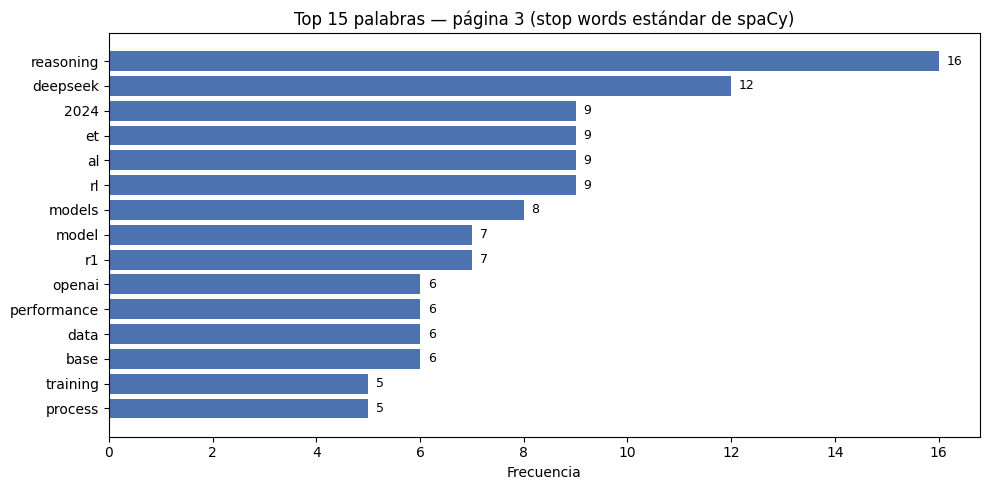

,Token,Frecuencia
0,reasoning,16
1,deepseek,12
2,2024,9
3,et,9
4,al,9
5,rl,9
6,models,8
7,model,7
8,r1,7
9,openai,6


In [22]:
def graficar_top(tokens, titulo, n=15, color="#4C72B0"):
    top = collections.Counter(tokens).most_common(n)
    palabras_top, frecuencias = zip(*top)
    plt.figure(figsize=(10, 5))
    plt.barh(palabras_top[::-1], frecuencias[::-1], color=color)
    for y, v in enumerate(frecuencias[::-1]):
        plt.text(v + 0.15, y, str(v), va="center", fontsize=9)
    plt.title(titulo)
    plt.xlabel("Frecuencia")
    plt.tight_layout()
    plt.show()
    return top

top15 = graficar_top(tokens_limpios, "Top 15 palabras — página 3 (stop words estándar de spaCy)")
pd.DataFrame(top15, columns=["Token", "Frecuencia"])

### 4.1 ¿Aparecieron tokens que también consideraría stop words?

Sí. En el top 15 hay varios tokens que **no aportan significado** al contenido de la página y que la lista estándar no filtró:

- **`et` y `al`**: vienen de las citas bibliográficas ("Lightman **et al.**, 2023"). spaCy separa "al." en `al` + `.`, y ninguno de los dos está en la lista de stop words del inglés porque son abreviaturas en **latín**. En un texto académico funcionan como stop words: aparecen en todas las citas y no dicen nada del tema.
- **`2024`**: también viene de las citas ("OpenAI, **2024**"). Es un año de publicación, no contenido. Los números sueltos se pueden filtrar con `token.like_num`.

Hay otros casos que **no** son stop words pero muestran problemas de normalización:
- **`model` / `models`** aparecen separados y se reparten la frecuencia. Con **lematización** (`token.lemma_`) se sumarían en un solo término.
- **`r1`, `o1`, `v3`, `rl`** son fragmentos de nombres propios ("DeepSeek-**R1**", "OpenAI **o1**", "DeepSeek-**V3**") o siglas (RL = *reinforcement learning*). spaCy parte "deepseek-r1" en `deepseek`, `-`, `r1`. No son ruido, pero si los quiero como una unidad conviene unirlos antes de tokenizar.

**Justificación:** que algo sea stop word **depende del dominio y de la tarea**. La lista de spaCy está pensada para inglés general. En un paper, las convenciones de citado (`et al.`, años) son "palabras funcionales" del género académico. Si el objetivo es saber de qué trata la página, conviene filtrarlas.

### 4.2 Versión mejorada (aporte propio)

Aplico tres mejoras: stop words del dominio académico, filtro de números y lematización.

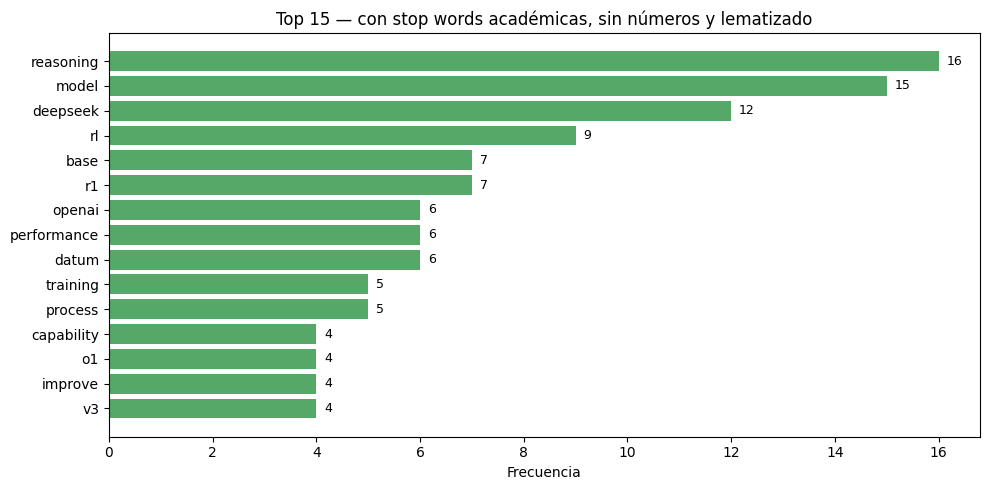

,Estándar,Mejorado
0,reasoning (16),reasoning (16)
1,deepseek (12),model (15)
2,2024 (9),deepseek (12)
3,et (9),rl (9)
4,al (9),base (7)
5,rl (9),r1 (7)
6,models (8),openai (6)
7,model (7),performance (6)
8,r1 (7),datum (6)
9,openai (6),training (5)


In [23]:
STOP_ACADEMICAS = {"et", "al", "e.g.", "i.e.", "etc", "fig", "figure", "table", "section"}

tokens_mejorados = [
    t.lemma_ for t in doc_spacy
    if not (t.is_stop or t.is_punct or t.is_space or t.like_num)
    and t.lemma_ not in STOP_ACADEMICAS
    and len(t.text) > 1
]

top15_mejorado = graficar_top(tokens_mejorados,
                              "Top 15 — con stop words académicas, sin números y lematizado",
                              color="#55A868")

comparacion = pd.DataFrame({
    "Estándar": [f"{w} ({c})" for w, c in top15],
    "Mejorado": [f"{w} ({c})" for w, c in top15_mejorado],
})
comparacion

Con la versión mejorada desaparecen `et`, `al` y `2024`. `model` sube porque ahora suma las apariciones de "model" y "models". Aparece un efecto curioso de la lematización: **`data` se convierte en `datum`** (su singular en latín). Es técnicamente correcto, pero en la práctica nadie dice "datum": muestra que la lematización también puede introducir sus propias rarezas. El ranking resume bastante bien de qué trata la introducción: **razonamiento (reasoning)**, **modelos DeepSeek**, **aprendizaje por refuerzo (RL)**, **rendimiento** y **entrenamiento**.

## 5. Conclusiones

1. **El PDF es un formato para "mostrar", no para "leer".** Internamente guarda instrucciones de dibujo: los espacios son desplazamientos, las palabras aparecen partidas por el kerning y las ligaduras ("fi") son un solo glifo. Por eso dos librerías pueden devolver textos distintos del mismo archivo (pdfplumber pegó palabras y PyMuPDF no).
2. **Los metadatos no son confiables.** Este PDF no trae título ni autor. Lo resolví infiriendo el título por el tamaño de fuente.
3. **El único separador de control es `\n`, y es ambiguo.** No hay `\r`, `\t`, `\f` ni líneas en blanco. Los párrafos, secciones y páginas se recuperan con **información geométrica y tipográfica** (bloques, negrita, numeración), no con el texto plano.
4. **Las tablas sin bordes rompen la extracción automática.** La solución fue combinar el recorte por coordenadas, las líneas horizontales para los grupos y expresiones regulares para las filas, y después validar el resultado (21 filas).
5. **Las stop words dependen del dominio.** En un texto académico hay que agregar `et`, `al`, años y referencias, y la lematización ayuda a no repartir la frecuencia entre singular y plural.

### Dificultades
- `extract_tables()` devolvía 0 tablas y la estrategia por texto devolvía celdas cortadas. Tuve que investigar cómo está hecha la tabla para entender por qué.
- Distinguir los guiones de corte de palabra de los guiones reales ("Chain-of-Thought").
- Darme cuenta de que el texto plano no tiene ninguna marca de párrafo.

### Qué aprendí
Antes de limpiar texto hay que **mirar cómo viene**: imprimir con `repr()`, contar caracteres y, si hace falta, bajar al *content stream*. Las decisiones de limpieza (qué separa un párrafo, qué es una stop word) no son universales: dependen del documento y del objetivo del análisis.

## Referencias

- DeepSeek-AI (2025). *DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning*. arXiv:2501.12948. https://arxiv.org/abs/2501.12948 — PDF usado: https://github.com/deepseek-ai/DeepSeek-R1/blob/main/DeepSeek_R1.pdf
- Documentación de PyMuPDF — extracción de texto (`get_text`, *blocks*, *dict*): https://pymupdf.readthedocs.io/en/latest/app1.html
- Documentación de pdfplumber — estrategias de detección de tablas: https://github.com/jsvine/pdfplumber#extracting-tables
- Documentación de spaCy — atributos de `Token` (`is_stop`, `is_punct`, `like_num`, `lemma_`): https://spacy.io/api/token
- Adobe (2008). *PDF Reference / ISO 32000-1*, sección 9.4 "Text Objects" (operadores `Tm`, `Td`, `TJ`).
- Requests — *Streaming downloads*: https://requests.readthedocs.io/en/latest/user/advanced/#body-content-workflow
- Material de la cátedra: notebook "Limpieza de texto parte 1" (A. L. Diedrichs) — https://github.com/anadiedrichs/procesamientoDelHabla
- Asistencia de IA: Claude (Anthropic) — Se solicito que brinde el material PDF en el cual no tenga problemas de derecho de autor y que sea relacionado a IA donde me permita realizar las actividades del TP2 y su respuesta fue: "TP2 (PDF): usé el reporte técnico de DeepSeek-R1, que se descarga con requests desde el repositorio público del proyecto en GitHub.

Metadatos: el PDF no trae título ni autor, así que el título lo saco de la primera página (es el texto con la letra más grande).
Separadores: el único carácter de control es \n (1.381 veces). No hay \r, \t, \f ni líneas en blanco. Los párrafos se recuperan por los bloques de texto de la página, y las secciones por la numeración en negrita. Hay una celda que muestra cómo está guardado el texto dentro del PDF: los espacios no existen como caracteres y las palabras aparecen cortadas.
Tabla: la Tabla 4 no tiene bordes y extract_tables() encuentra 0 tablas. La extraigo recortando la zona de la página y usando las líneas horizontales y expresiones regulares, y verifico que salgan las 21 filas. En el primer análisis salió algo interesante: según cómo se traten los datos faltantes, el modelo que "gana" se invierte.
Stop words: en el top 15 aparecen et, al y 2024, que vienen de las citas. Lo justifico y agrego una versión mejorada con lematización."